# GANs con PyTorch

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jorobledo/apbf/blob/main/APBF/teorico_practicos/Semana05_GANs.ipynb)

En esta notebook vamos a construir una introduccion didactica a las **Generative Adversarial Networks (GANs)**.

La idea central de una GAN es entrenar dos redes en simultaneo:

- un **generador** que produce muestras falsas;
- un **discriminador** que intenta distinguir muestras reales de falsas.

Objetivos de aprendizaje:

- entender la logica adversarial detras de una GAN;
- implementar un generador y un discriminador en PyTorch;
- entrenar ambos modelos de forma alternada;
- visualizar como una distribucion simple de ruido se transforma en datos con estructura.


## Librerias necesarias

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 70
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", DEVICE)
print("Torch:", torch.__version__)

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True


Dispositivo: cpu
Torch: 2.5.1


## Parte 1

### Dataset 2D: dos medias lunas

En imagenes, una GAN transforma un vector latente en una imagen. Para entender el mecanismo sin distraernos con arquitecturas grandes, trabajaremos con un dataset bidimensional.

Si la GAN aprende correctamente, deberia generar puntos con una forma parecida a las dos medias lunas reales.


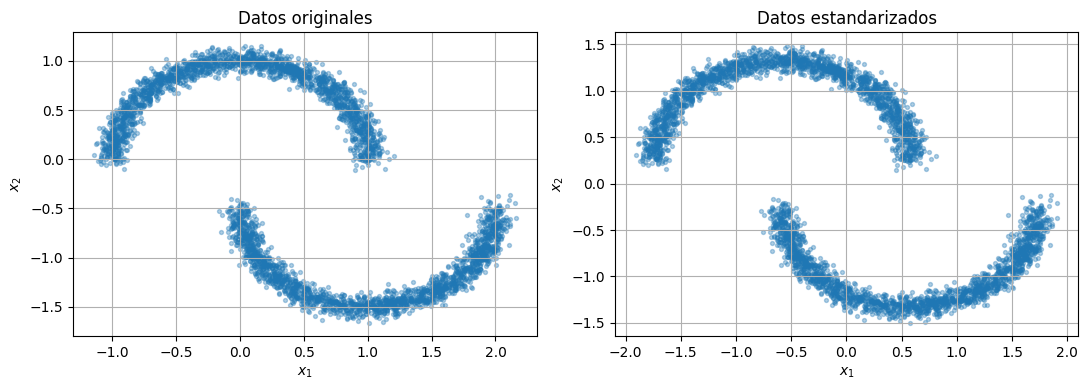

In [2]:
def sample_two_moons(n_samples=4000, noise=0.06, device=DEVICE):
    n1 = n_samples // 2
    n2 = n_samples - n1

    theta1 = torch.rand(n1, device=device) * math.pi
    theta2 = torch.rand(n2, device=device) * math.pi

    moon1 = torch.stack([torch.cos(theta1), torch.sin(theta1)], dim=1)
    moon2 = torch.stack([1.0 - torch.cos(theta2), -torch.sin(theta2) - 0.5], dim=1)

    x = torch.cat([moon1, moon2], dim=0)
    x = x + noise * torch.randn_like(x)

    perm = torch.randperm(x.size(0), device=device)
    return x[perm]


class Standardizer:
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def encode(self, x):
        return (x - self.mean) / self.std

    def decode(self, x):
        return x * self.std + self.mean


def make_standardizer(x):
    mean = x.mean(0, keepdim=True)
    std = x.std(0, keepdim=True).clamp_min(1e-4)
    return Standardizer(mean=mean, std=std)


def scatter_2d(x, ax=None, title="", alpha=0.35, s=8, color="#1f77b4"):
    if ax is None:
        _, ax = plt.subplots()
    x = x.detach().cpu()
    ax.scatter(x[:, 0], x[:, 1], s=s, alpha=alpha, color=color)
    ax.set_title(title)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    return ax


raw_data = sample_two_moons()
standardizer = make_standardizer(raw_data)
train_data = standardizer.encode(raw_data)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
scatter_2d(raw_data, ax=axes[0], title="Datos originales")
scatter_2d(train_data, ax=axes[1], title="Datos estandarizados")
plt.tight_layout()
plt.show()


## Parte 2

### La idea adversarial

En una GAN clasica, el generador transforma un vector latente $z \sim p(z)$ en una muestra sintética $G(z)$.

El discriminador recibe una muestra $x$ y devuelve un escalar $D(x)$, que idealmente indica cuan probable es que esa muestra sea real.

El juego minimax original puede escribirse como:

$$
\min_G \max_D\; \mathbb E_{x \sim p_{data}}[\log D(x)] + \mathbb E_{z \sim p(z)}[\log(1 - D(G(z)))].
$$

Lectura intuitiva:

- el discriminador quiere asignar valor alto a datos reales y bajo a datos falsos;
- el generador quiere producir muestras que el discriminador no pueda distinguir de las reales.

En la practica, solemos entrenar con `BCEWithLogitsLoss`, que combina una sigmoide y la entropia cruzada binaria de forma numericamente estable.


## Parte 3

### Arquitecturas: generador y discriminador

Como el dataset es 2D, usaremos dos MLPs pequeñas.

El generador recibirá un vector latente de dimensión 2 y devolverá un punto 2D.

El discriminador recibira un punto 2D y devolverá un logit escalar. No aplicamos sigmoide al final porque la función de perdida ya la incorpora internamente.


In [4]:
LATENT_DIM = 2


class MLP(nn.Module):
    def __init__(self, in_features, out_features, hidden_features=(64, 64), activation=nn.LeakyReLU):
        super().__init__()
        dims = [in_features, *hidden_features, out_features]
        layers = []
        for din, dout in zip(dims[:-2], dims[1:-1]):
            layers.append(nn.Linear(din, dout))
            if activation is nn.LeakyReLU:
                layers.append(activation(0.2))
            else:
                layers.append(activation())
        layers.append(nn.Linear(dims[-2], dims[-1]))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class Generator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, data_dim=2):
        super().__init__()
        self.net = MLP(latent_dim, data_dim, hidden_features=(128, 128), activation=nn.ReLU)

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self, data_dim=2):
        super().__init__()
        self.net = MLP(data_dim, 1, hidden_features=(128, 128), activation=nn.LeakyReLU)

    def forward(self, x):
        return self.net(x)


generator = Generator().to(DEVICE)
discriminator = Discriminator().to(DEVICE)

print(generator)
print(discriminator)


Generator(
  (net): MLP(
    (net): Sequential(
      (0): Linear(in_features=2, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): ReLU()
      (4): Linear(in_features=128, out_features=2, bias=True)
    )
  )
)
Discriminator(
  (net): MLP(
    (net): Sequential(
      (0): Linear(in_features=2, out_features=128, bias=True)
      (1): LeakyReLU(negative_slope=0.2)
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): LeakyReLU(negative_slope=0.2)
      (4): Linear(in_features=128, out_features=1, bias=True)
    )
  )
)


## Parte 4

### Entrenamiento alternado

En cada iteración hacemos dos pasos:

1. actualizamos el discriminador usando ejemplos reales y ejemplos falsos generados por el generador actual;
2. actualizamos el generador para que los ejemplos falsos reciban etiqueta de reales segun el discriminador.

Esto no es una optimización tradicional sobre una sola función de costo. Es un juego entre dos redes, y por eso el entrenamiento puede ser sensible a hiperparámetros y arquitecturas.


In [19]:
bce_logits = nn.BCEWithLogitsLoss()


def sample_latent(n_samples, latent_dim=LATENT_DIM, device=DEVICE):
    return torch.randn(n_samples, latent_dim, device=device)


@torch.no_grad()
def generate_samples(generator, n_samples):
    z = sample_latent(n_samples, device=next(generator.parameters()).device)
    return generator(z)


def train_gan(generator, discriminator, data, epochs=800, batch_size=64, lr=1e-3, verbose_every=100):
    generator = generator.to(DEVICE)
    discriminator = discriminator.to(DEVICE)
    data = data.to(DEVICE)

    g_optimizer = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

    history = {"g_loss": [], "d_loss": [], "real_score": [], "fake_score": []}

    for epoch in range(1, epochs + 1):
        perm = torch.randperm(data.size(0), device=data.device)
        total_g = 0.0
        total_d = 0.0
        total_real_score = 0.0
        total_fake_score = 0.0
        n_seen = 0

        for i in range(0, data.size(0), batch_size):
            idx = perm[i : i + batch_size]
            real_batch = data[idx]
            current_batch_size = real_batch.size(0)

            real_targets = torch.ones(current_batch_size, 1, device=data.device)
            fake_targets = torch.zeros(current_batch_size, 1, device=data.device)

            z = sample_latent(current_batch_size, device=data.device)
            fake_batch = generator(z)

            real_logits = discriminator(real_batch)
            fake_logits = discriminator(fake_batch.detach())

            d_loss_real = bce_logits(real_logits, real_targets)
            d_loss_fake = bce_logits(fake_logits, fake_targets)
            d_loss = 0.5 * (d_loss_real + d_loss_fake)

            d_optimizer.zero_grad()
            d_loss.backward()
            d_optimizer.step()

            z = sample_latent(current_batch_size, device=data.device)
            generated_batch = generator(z)
            generated_logits = discriminator(generated_batch)

            g_loss = bce_logits(generated_logits, real_targets)

            g_optimizer.zero_grad()
            g_loss.backward()
            g_optimizer.step()

            total_d += d_loss.item() * current_batch_size
            total_g += g_loss.item() * current_batch_size
            total_real_score += torch.sigmoid(real_logits).mean().item() * current_batch_size
            total_fake_score += torch.sigmoid(fake_logits).mean().item() * current_batch_size
            n_seen += current_batch_size

        history["d_loss"].append(total_d / n_seen)
        history["g_loss"].append(total_g / n_seen)
        history["real_score"].append(total_real_score / n_seen)
        history["fake_score"].append(total_fake_score / n_seen)

        if epoch % verbose_every == 0 or epoch == 1:
            print(
                f"epoch={epoch:4d}  d_loss={history['d_loss'][-1]:.4f}  "
                f"g_loss={history['g_loss'][-1]:.4f}  "
                f"D(real)={history['real_score'][-1]:.3f}  "
                f"D(fake)={history['fake_score'][-1]:.3f}"
            )

    return history


history = train_gan(generator, discriminator, train_data)


epoch=   1  d_loss=0.6936  g_loss=0.6936  D(real)=0.500  D(fake)=0.501
epoch= 100  d_loss=0.6934  g_loss=0.6926  D(real)=0.500  D(fake)=0.501
epoch= 200  d_loss=0.6932  g_loss=0.6932  D(real)=0.500  D(fake)=0.500
epoch= 300  d_loss=0.6932  g_loss=0.6941  D(real)=0.500  D(fake)=0.500
epoch= 400  d_loss=0.6930  g_loss=0.6935  D(real)=0.500  D(fake)=0.500
epoch= 500  d_loss=0.6934  g_loss=0.6946  D(real)=0.500  D(fake)=0.500
epoch= 600  d_loss=0.6932  g_loss=0.6943  D(real)=0.500  D(fake)=0.500
epoch= 700  d_loss=0.6933  g_loss=0.6942  D(real)=0.500  D(fake)=0.500
epoch= 800  d_loss=0.6932  g_loss=0.6933  D(real)=0.500  D(fake)=0.500


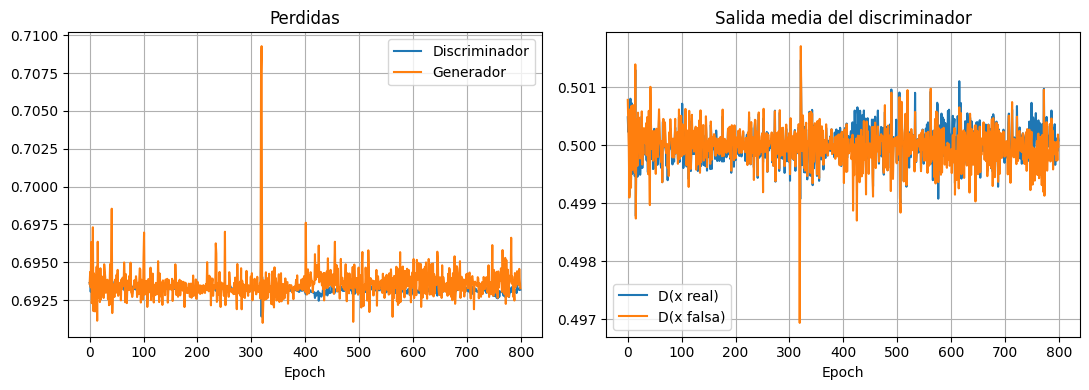

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history["d_loss"], label="Discriminador")
axes[0].plot(history["g_loss"], label="Generador")
axes[0].set_title("Perdidas")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["real_score"], label="D(x real)")
axes[1].plot(history["fake_score"], label="D(x falsa)")
axes[1].set_title("Salida media del discriminador")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


## Parte 5

### Que aprendio el generador

Ahora comparamos muestras reales con muestras sintéticas.

Si el entrenamiento fue razonable, los puntos generados no deberían quedar simplemente como una nube gaussiana, sino aproximar la geometría curva del dataset.

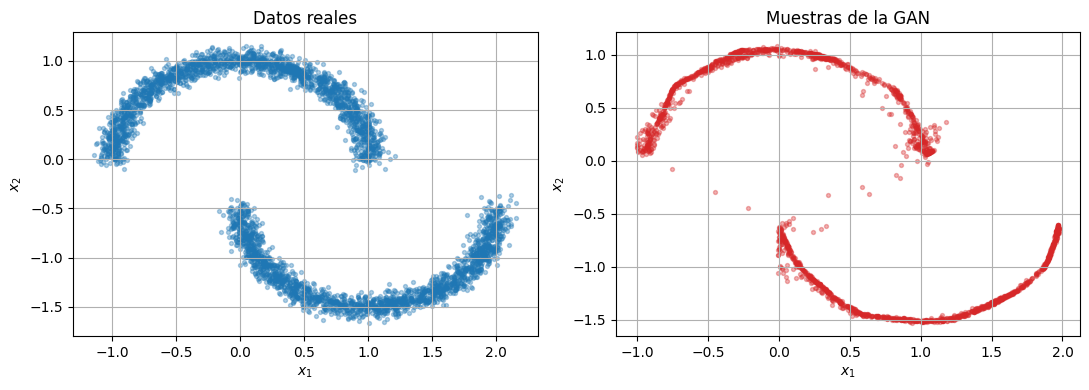

In [21]:
@torch.no_grad()
def compare_samples(reference, generated, title_left="Datos", title_right="Muestras"):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    scatter_2d(reference, ax=axes[0], title=title_left, color="#1f77b4")
    scatter_2d(generated, ax=axes[1], title=title_right, color="#d62728")
    plt.tight_layout()
    plt.show()


generated = generate_samples(generator, 2000).cpu()
generated_decoded = standardizer.decode(generated)
compare_samples(raw_data.cpu(), generated_decoded, title_left="Datos reales", title_right="Muestras de la GAN")


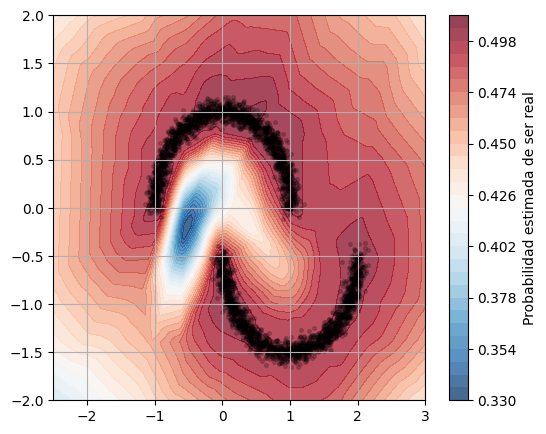

In [22]:
@torch.no_grad()
def discriminator_surface(discriminator, standardizer, xlim=(-2.5, 3.0), ylim=(-2.0, 2.0), steps=220):
    xs = torch.linspace(xlim[0], xlim[1], steps)
    ys = torch.linspace(ylim[0], ylim[1], steps)
    xx, yy = torch.meshgrid(xs, ys, indexing="xy")
    grid = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1)
    standardized_grid = standardizer.encode(grid.to(DEVICE))
    logits = discriminator(standardized_grid)
    probs = torch.sigmoid(logits).reshape(steps, steps).cpu()
    return xx, yy, probs


xx, yy, probs = discriminator_surface(discriminator, standardizer)

plt.figure(figsize=(6, 5))
plt.contourf(xx.numpy(), yy.numpy(), probs.numpy(), levels=30, cmap="RdBu_r", alpha=0.75)
plt.colorbar(label="Probabilidad estimada de ser real")
plt.scatter(raw_data.cpu().T[0], raw_data.cpu().T[1], alpha=0.18, s=7, color="black")
plt.show()


La figura de la superficie del discriminador muestra algo importante: el discriminador no memoriza etiquetas aisladas, sino que aprende regiones del espacio donde considera mas plausible encontrar datos reales.

El generador usa gradientes provenientes de esa superficie para deformar su distribucion latente y empujar sus muestras hacia regiones que el discriminador juzga mas realistas.


### Dificultades tipicas de las GANs

Las GANs son potentes, pero tambien son notoriamente delicadas de entrenar.

Problemas clasicos:

- **mode collapse**: el generador produce pocas variantes y se concentra en una sola region de la distribucion;
- **discriminador demasiado fuerte**: si separa reales y falsos demasiado facil, el generador recibe gradientes pobres;
- **oscilaciones**: como es un juego entre dos redes, las perdidas pueden no bajar de forma monotona.

Algunas tecnicas habituales para mejorar estabilidad:

- usar `Adam` con `betas=(0.5, 0.999)`;
- normalizacion o regularizacion apropiada;
- objetivos alternativos como **WGAN** o **hinge loss**;
- arquitecturas convolucionales al trabajar con imagenes.
